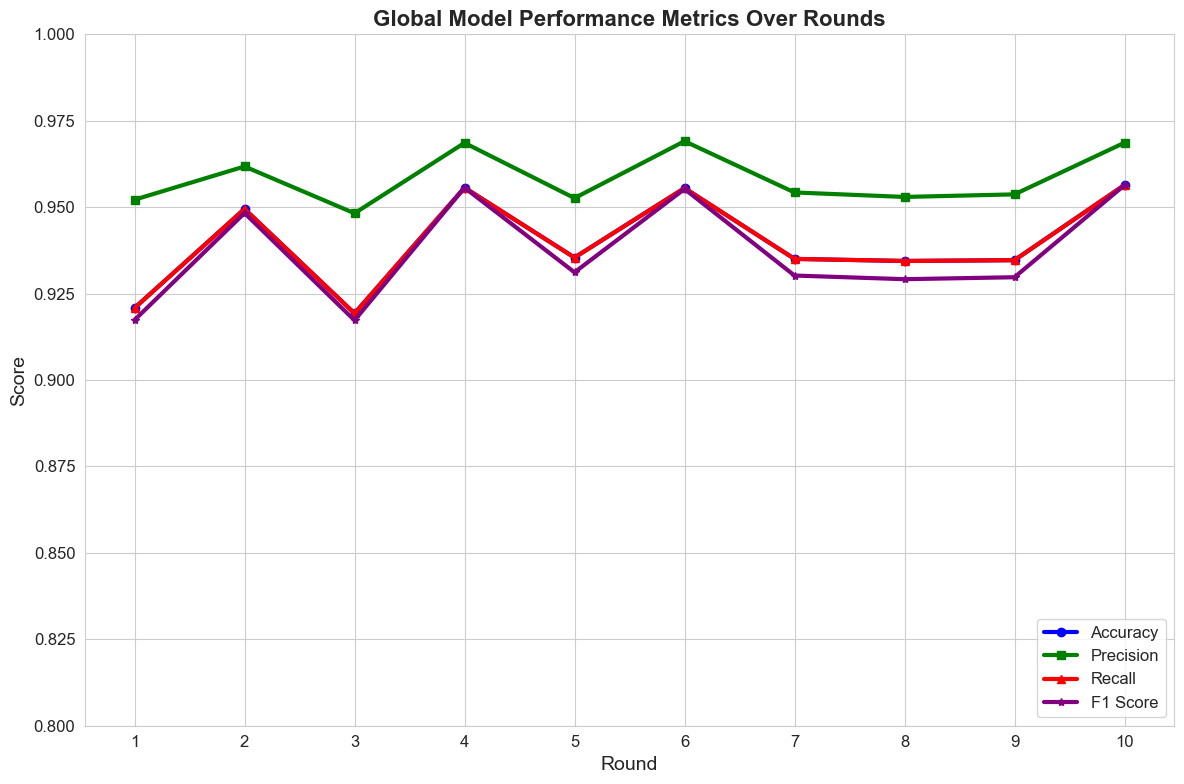

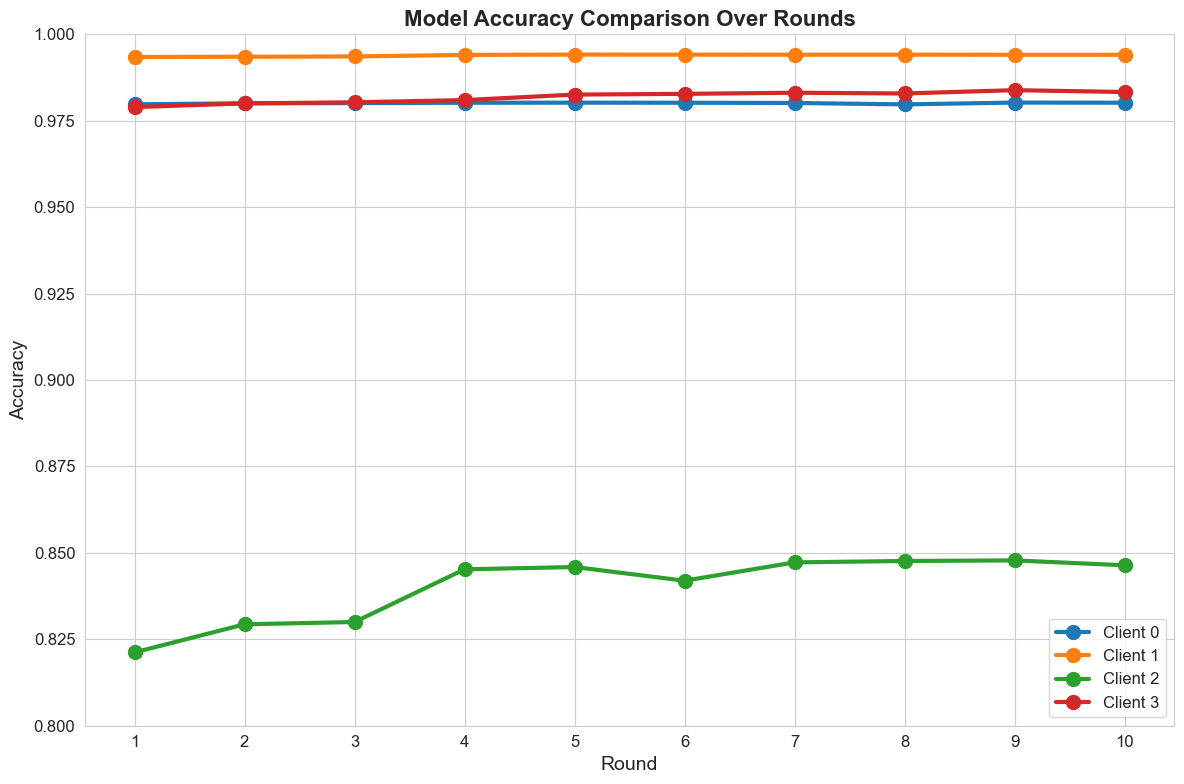

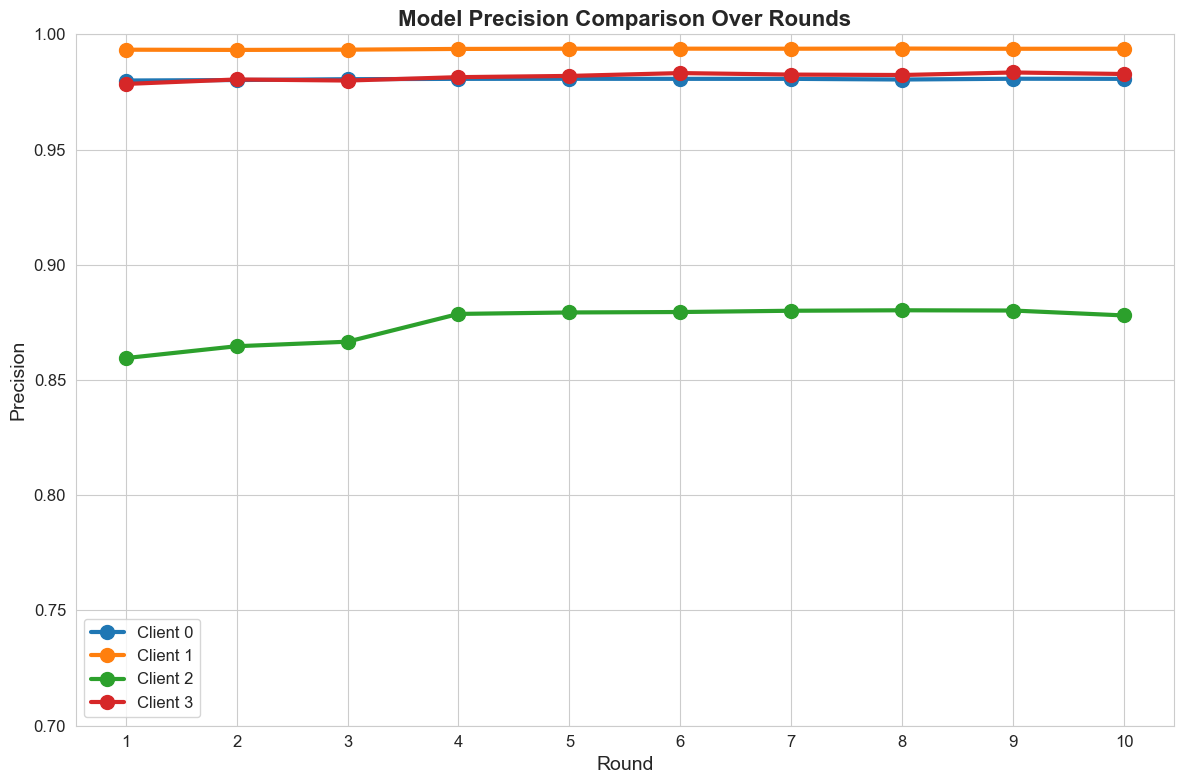

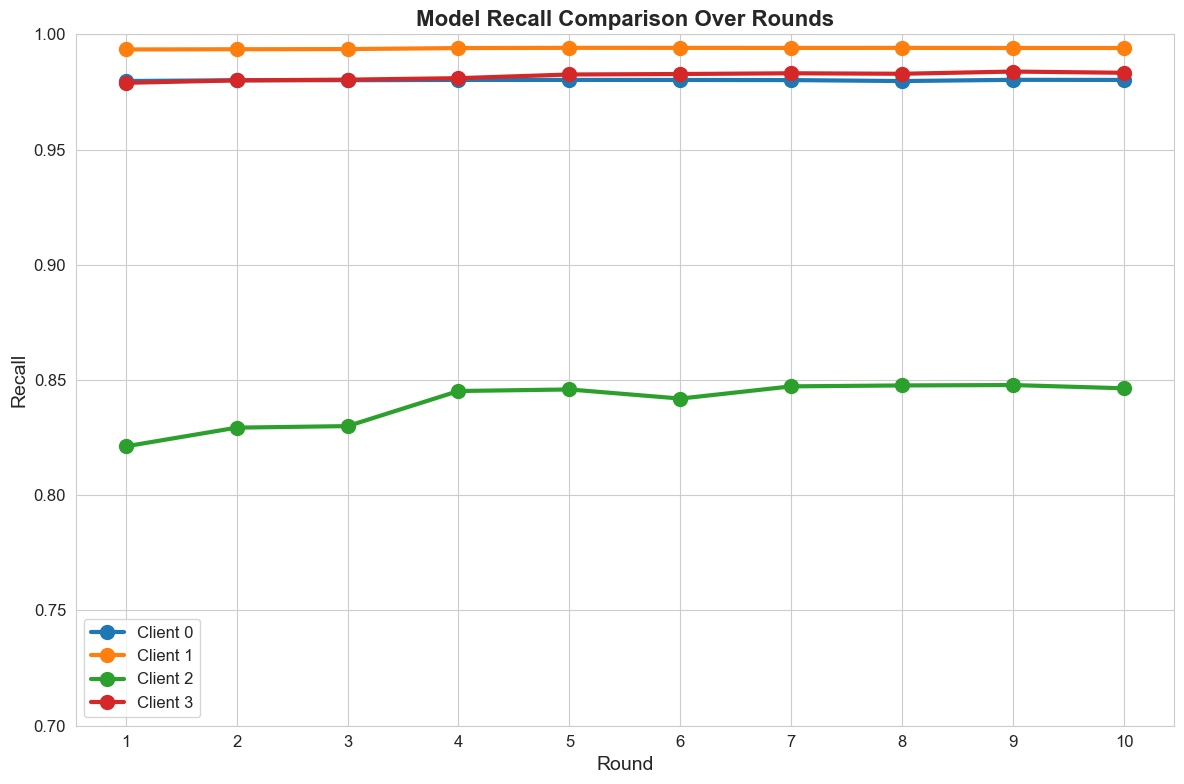

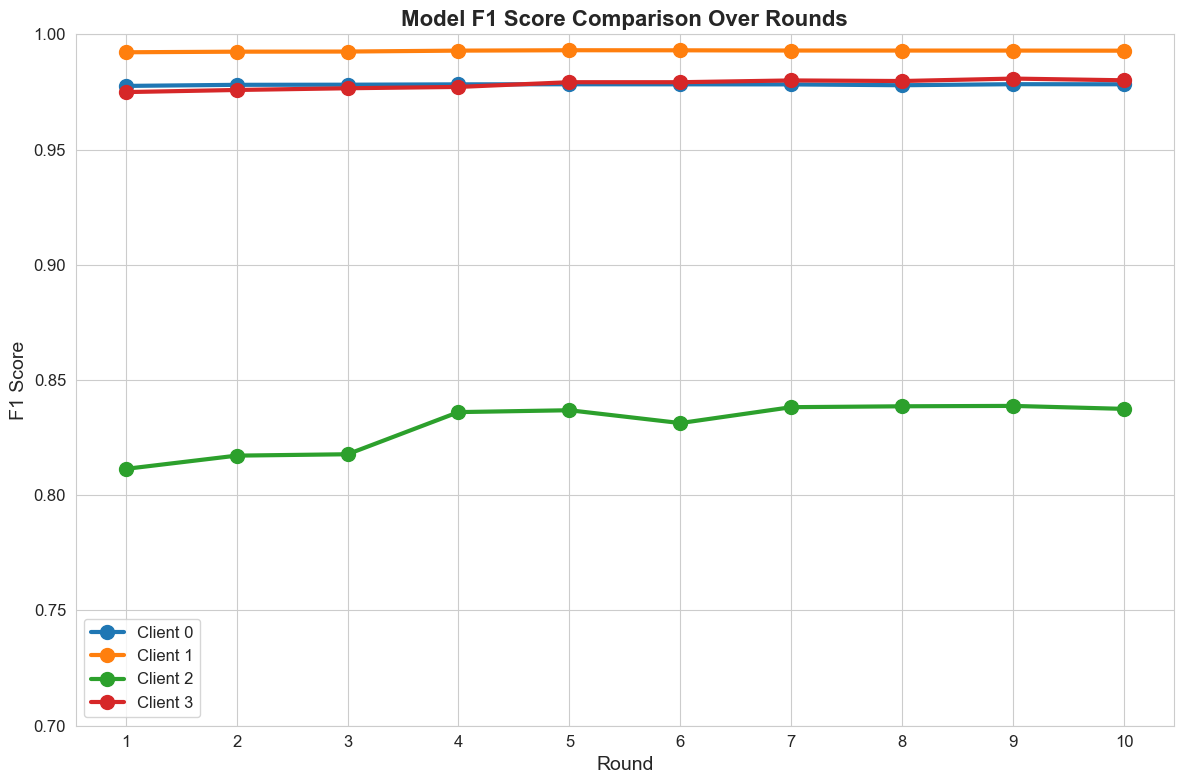

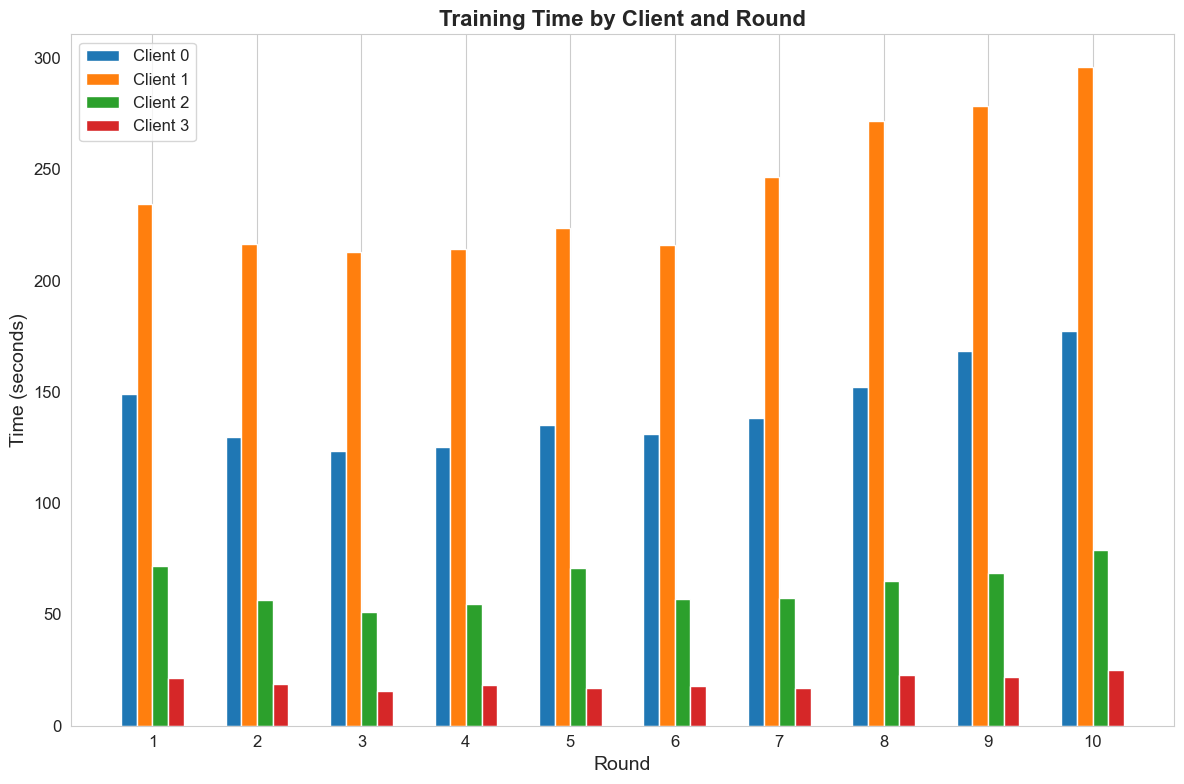

Average training time for Client 0: 143.04 seconds
Average training time for Client 1: 240.98 seconds
Average training time for Client 2: 63.13 seconds
Average training time for Client 3: 19.55 seconds
Overall average training time for all clients: 116.67 seconds


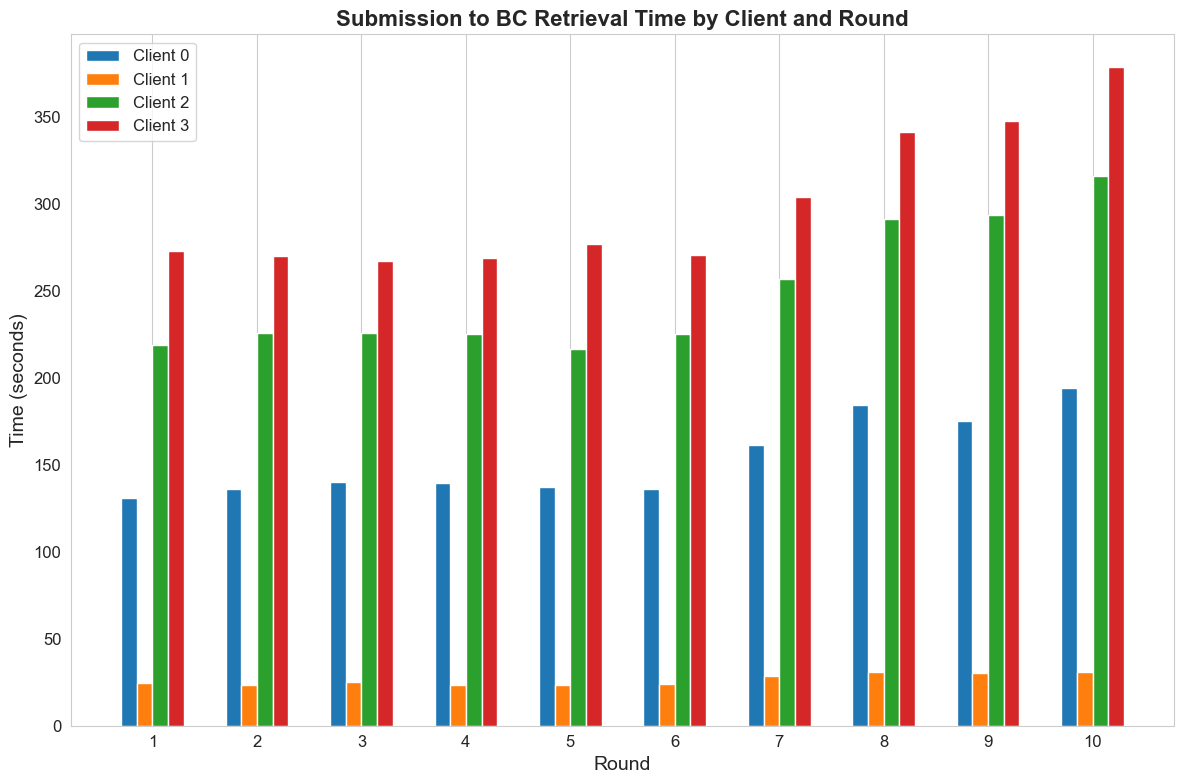

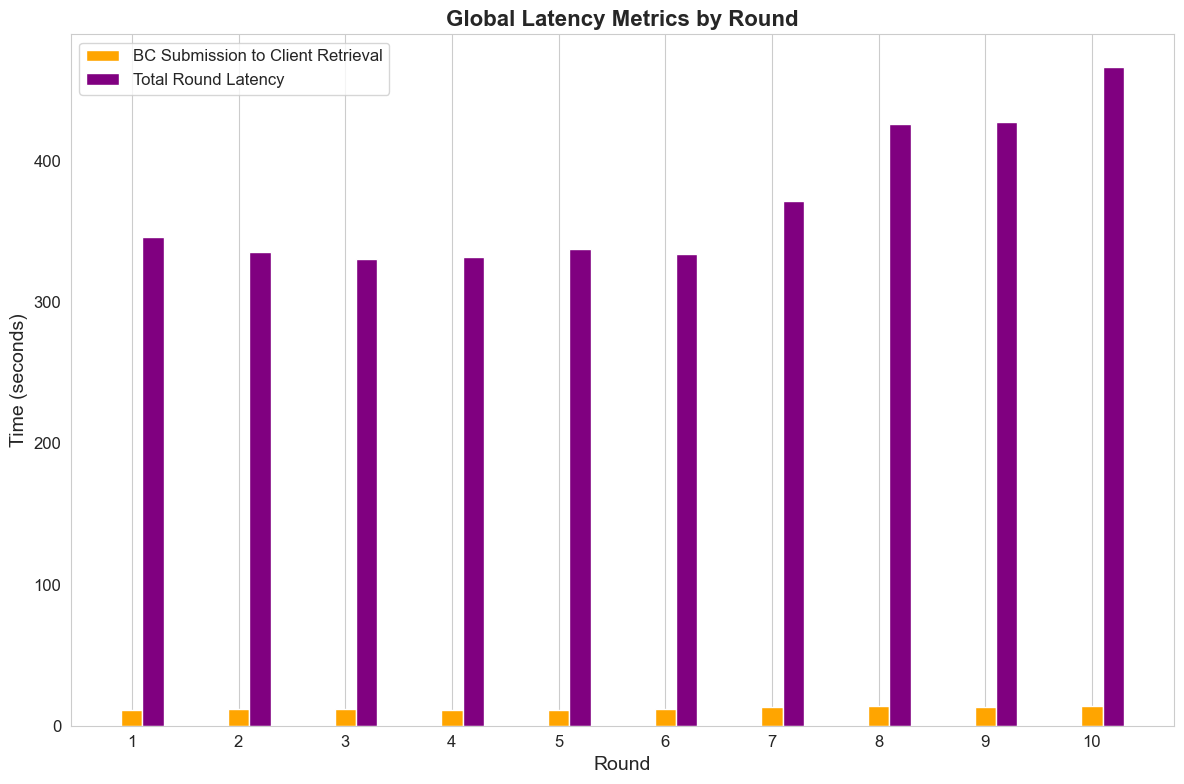

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
import pandas as pd

# Load the metrics data from file
with open('fl_metrics-4c.json', 'r') as f:
    metrics = json.load(f)

# Set a consistent style for all plots
sns.set_style("whitegrid")
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.titlesize': 18
})

# Extract rounds data
rounds_data = metrics['rounds']
num_rounds = len(rounds_data)
rounds = range(1, num_rounds + 1)

# 1. Global Model Performance Over Rounds
plt.figure(figsize=(12, 8))

# Extract metrics for global model
global_accuracy = [round_data['global_model']['accuracy'] for round_data in rounds_data]
global_precision = [round_data['global_model']['precision'] for round_data in rounds_data]
global_recall = [round_data['global_model']['recall'] for round_data in rounds_data]
global_f1 = [round_data['global_model']['f1_score'] for round_data in rounds_data]

plt.plot(rounds, global_accuracy, marker='o', linewidth=3, label='Accuracy', color='blue')
plt.plot(rounds, global_precision, marker='s', linewidth=3, label='Precision', color='green')
plt.plot(rounds, global_recall, marker='^', linewidth=3, label='Recall', color='red')
plt.plot(rounds, global_f1, marker='*', linewidth=3, label='F1 Score', color='purple')

plt.title('Global Model Performance Metrics Over Rounds', fontweight='bold')
plt.xlabel('Round')
plt.ylabel('Score')
plt.xticks(rounds)
plt.ylim(0.8, 1)  # Set y-axis scale as requested
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.savefig('results/global_model_performance.png', dpi=300)
plt.show()

# 2. Client Accuracy Over Rounds
plt.figure(figsize=(12, 8))

for client_id in range(4):  # Assuming 4 clients
    client_accuracies = [round_data['local_models'][str(client_id)]['accuracy'] for round_data in rounds_data]
    plt.plot(rounds, client_accuracies, marker='o', linewidth=3, markersize=10, label=f'Client {client_id}')

plt.title('Model Accuracy Comparison Over Rounds', fontweight='bold')
plt.xlabel('Round')
plt.ylabel('Accuracy')
plt.xticks(rounds)
plt.ylim(0.8, 1)  # Set y-axis scale as requested
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('results/client_accuracy_comparison.png', dpi=300)
plt.show()

# 3. Client Precision Over Rounds
plt.figure(figsize=(12, 8))

for client_id in range(4):
    client_precision = [round_data['local_models'][str(client_id)]['precision'] for round_data in rounds_data]
    plt.plot(rounds, client_precision, marker='o', linewidth=3, markersize=10, label=f'Client {client_id}')


plt.title('Model Precision Comparison Over Rounds', fontweight='bold')
plt.xlabel('Round')
plt.ylabel('Precision')
plt.xticks(rounds)
plt.ylim(0.7, 1)  # Set y-axis scale as requested
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('results/client_precision_comparison.png', dpi=300)
plt.show()

# 4. Client Recall Over Rounds
plt.figure(figsize=(12, 8))

for client_id in range(4):
    client_recall = [round_data['local_models'][str(client_id)]['recall'] for round_data in rounds_data]
    plt.plot(rounds, client_recall, marker='o', linewidth=3, markersize=10, label=f'Client {client_id}')


plt.title('Model Recall Comparison Over Rounds', fontweight='bold')
plt.xlabel('Round')
plt.ylabel('Recall')
plt.xticks(rounds)
plt.ylim(0.7, 1)  # Set y-axis scale as requested
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('results/client_recall_comparison.png', dpi=300)
plt.show()

# 5. Client F1 Score Over Rounds
plt.figure(figsize=(12, 8))

for client_id in range(4):
    client_f1 = [round_data['local_models'][str(client_id)]['f1_score'] for round_data in rounds_data]
    plt.plot(rounds, client_f1, marker='o', linewidth=3, markersize=10, label=f'Client {client_id}')


plt.title('Model F1 Score Comparison Over Rounds', fontweight='bold')
plt.xlabel('Round')
plt.ylabel('F1 Score')
plt.xticks(rounds)
plt.ylim(0.7, 1)  # Set y-axis scale as requested
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('results/client_f1_comparison.png', dpi=300)
plt.show()

# 6. Latency metrics

# 6.1 Training Time Comparison
plt.figure(figsize=(12, 8))

for client_id in range(4):
    training_times = [round_data['local_models'][str(client_id)]['training_time'] for round_data in rounds_data]
    plt.bar(np.array(rounds) + 0.15 * client_id - 0.225, training_times, width=0.15, label=f'Client {client_id}')

plt.title('Training Time by Client and Round', fontweight='bold')
plt.xlabel('Round')
plt.ylabel('Time (seconds)')
plt.xticks(rounds)
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.savefig('results/training_time_comparison.png', dpi=300)
plt.show()
# calculate average training time 
for client_id in range(4):
    training_times = [round_data['local_models'][str(client_id)]['training_time'] for round_data in rounds_data]
    avg_training_time = sum(training_times) / len(training_times)
    print(f'Average training time for Client {client_id}: {avg_training_time:.2f} seconds')
# print average training time for all clients
avg_training_time_all_clients = []
for client_id in range(4):
    training_times = [round_data['local_models'][str(client_id)]['training_time'] for round_data in rounds_data]
    avg_training_time = sum(training_times) / len(training_times)
    avg_training_time_all_clients.append(avg_training_time)
overall_avg_training_time = sum(avg_training_time_all_clients) / len(avg_training_time_all_clients)
print(f'Overall average training time for all clients: {overall_avg_training_time:.2f} seconds')
# 6.2 Blockchain Retrieval Time Comparison
plt.figure(figsize=(12, 8))

for client_id in range(4):
    bc_retrieval_times = [round_data['local_models'][str(client_id)]['submission_to_bc_retrieval_time'] for round_data in rounds_data]
    plt.bar(np.array(rounds) + 0.15 * client_id - 0.225, bc_retrieval_times, width=0.15, label=f'Client {client_id}')

plt.title('Submission to BC Retrieval Time by Client and Round', fontweight='bold')
plt.xlabel('Round')
plt.ylabel('Time (seconds)')
plt.xticks(rounds)
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.savefig('results/bc_retrieval_time_comparison.png', dpi=300)
plt.show()

# 6.3 Global Blockchain and Aggregation Times
plt.figure(figsize=(12, 8))

# Extract times
#aggregation_times = [round_data['global_model']['aggregation_time'] for round_data in rounds_data]
bc_client_retrieval_times = [round_data['global_model']['bc_submission_to_client_retrieval_time'] for round_data in rounds_data]
total_latencies = [round_data['total_latency'] for round_data in rounds_data]

# Create bar chart with different widths and positions
#plt.bar(np.array(rounds) - 0.2, aggregation_times, width=0.2, color='green', label='Aggregation Time')
plt.bar(np.array(rounds), bc_client_retrieval_times, width=0.2, color='orange', label='BC Submission to Client Retrieval')
plt.bar(np.array(rounds) + 0.2, total_latencies, width=0.2, color='purple', label='Total Round Latency')

plt.title('Global Latency Metrics by Round', fontweight='bold')
plt.xlabel('Round')
plt.ylabel('Time (seconds)')
plt.xticks(rounds)
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.savefig('results/global_latency_metrics.png', dpi=300)
plt.show()

# 7. Confusion Matrices Visualization
# Create a function to plot confusion matrices
def plot_confusion_matrix(cm, classes, round_num, model_type, client_id=None):
    """
    Plot confusion matrix for a model
    """
    plt.figure(figsize=(10, 8))
    
    # Normalize the confusion matrix
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    cm_normalized = np.nan_to_num(cm_normalized)  # Replace NaN with 0
    
    sns.heatmap(cm_normalized, annot=cm, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes, cbar=False)
    
    title = f'Confusion Matrix'
    if model_type == 'global':
        title += ' - Global Model'
    else:
        title += f' - Client {client_id}'
    
    plt.title(title, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    
    # Save the figure
    if model_type == 'global':
        filename = f'results/confusion_matrix_round_{round_num}_global.png'
    else:
        filename = f'results/confusion_matrix_round_{round_num}_client_{client_id}.png'
    
    plt.savefig(filename, dpi=300)
    plt.show()


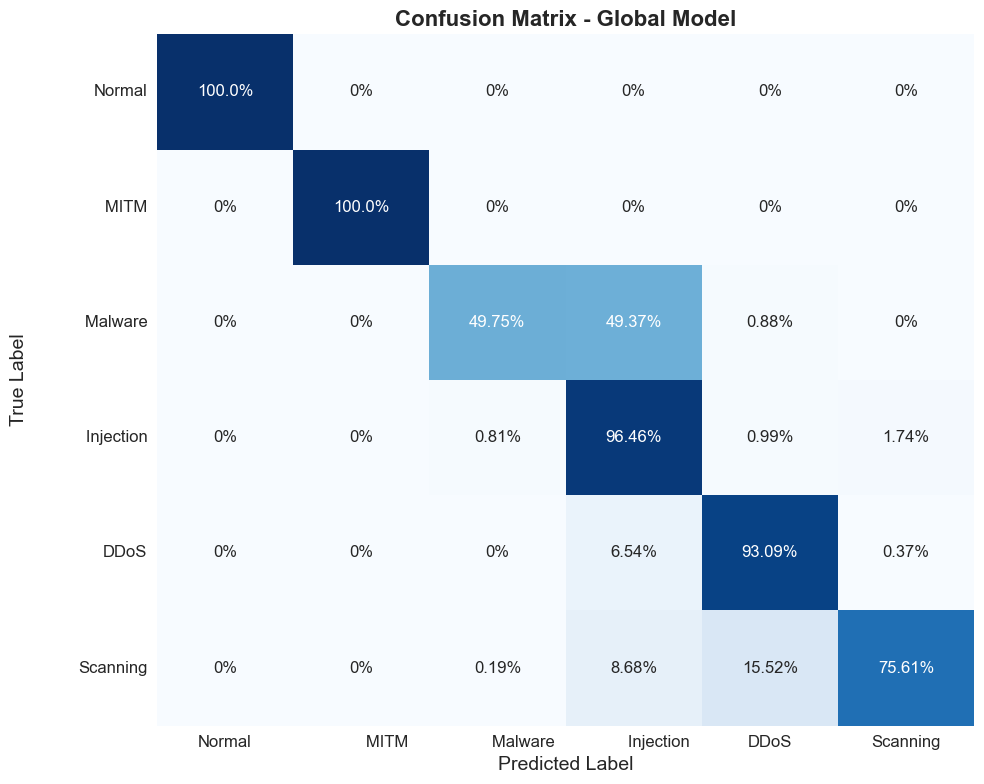

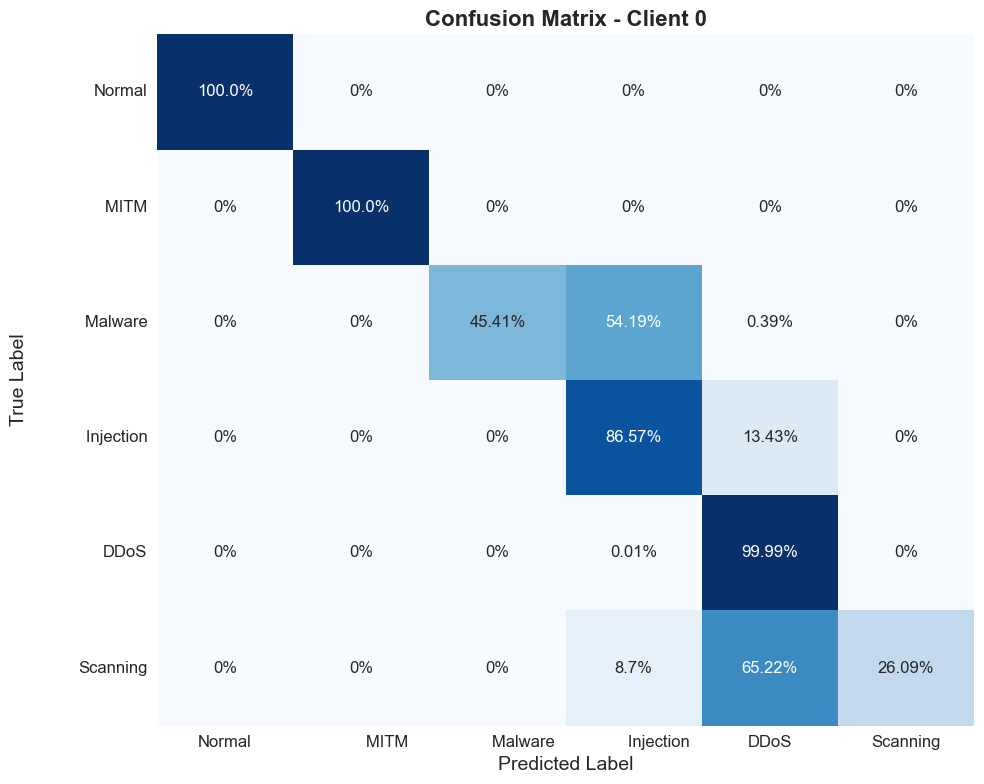

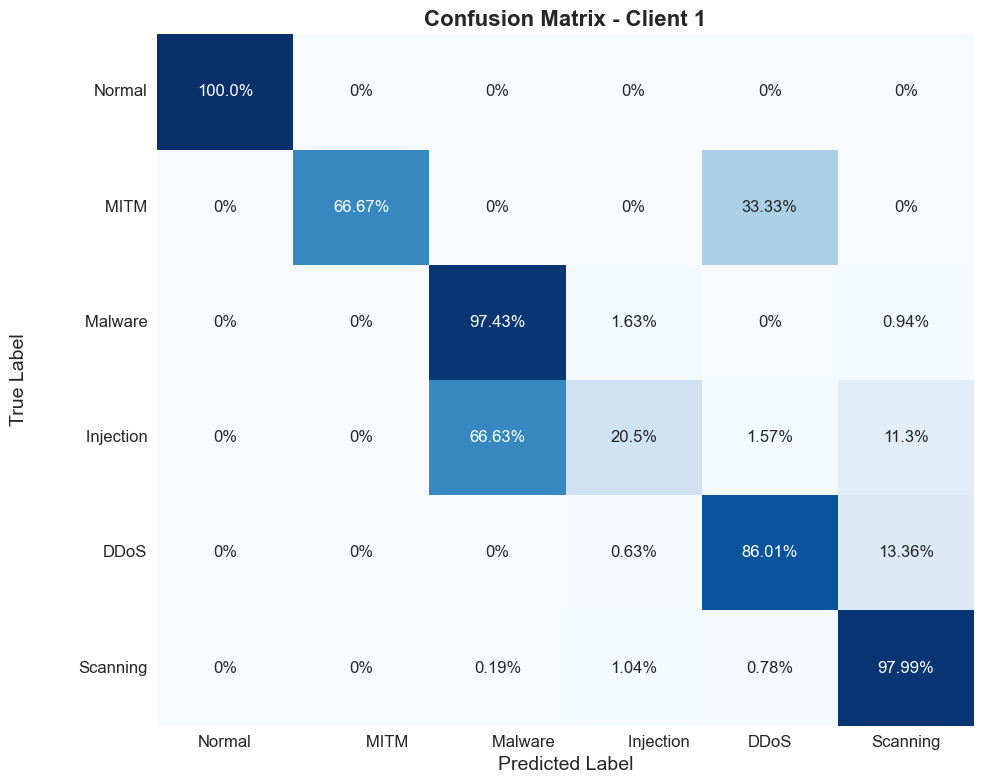

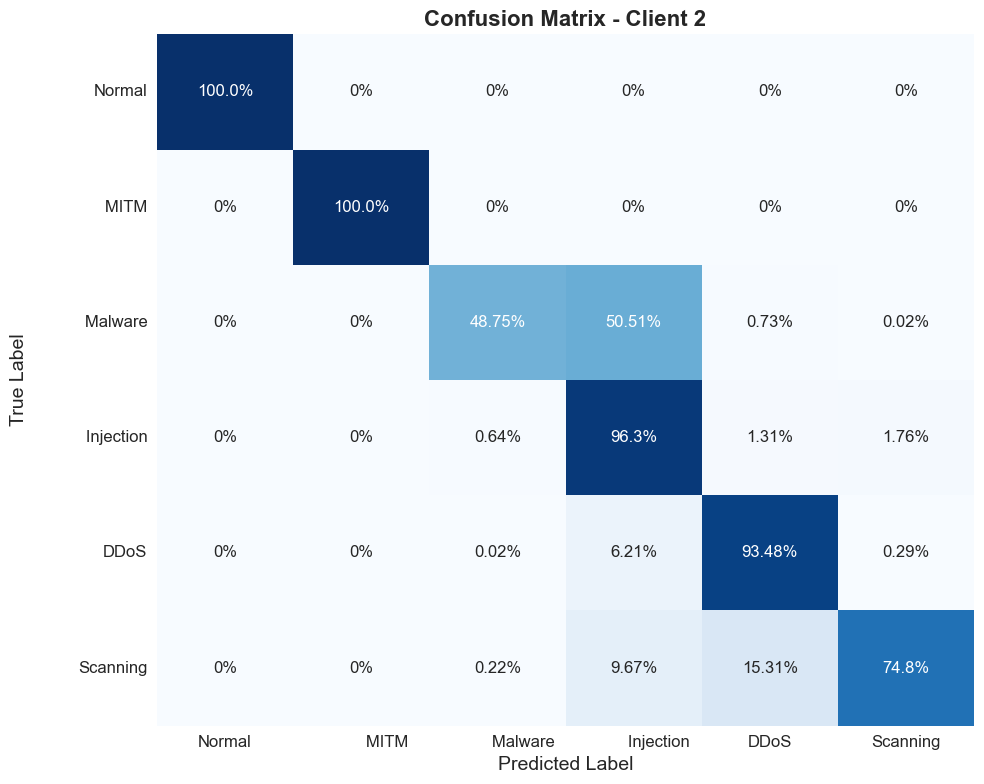

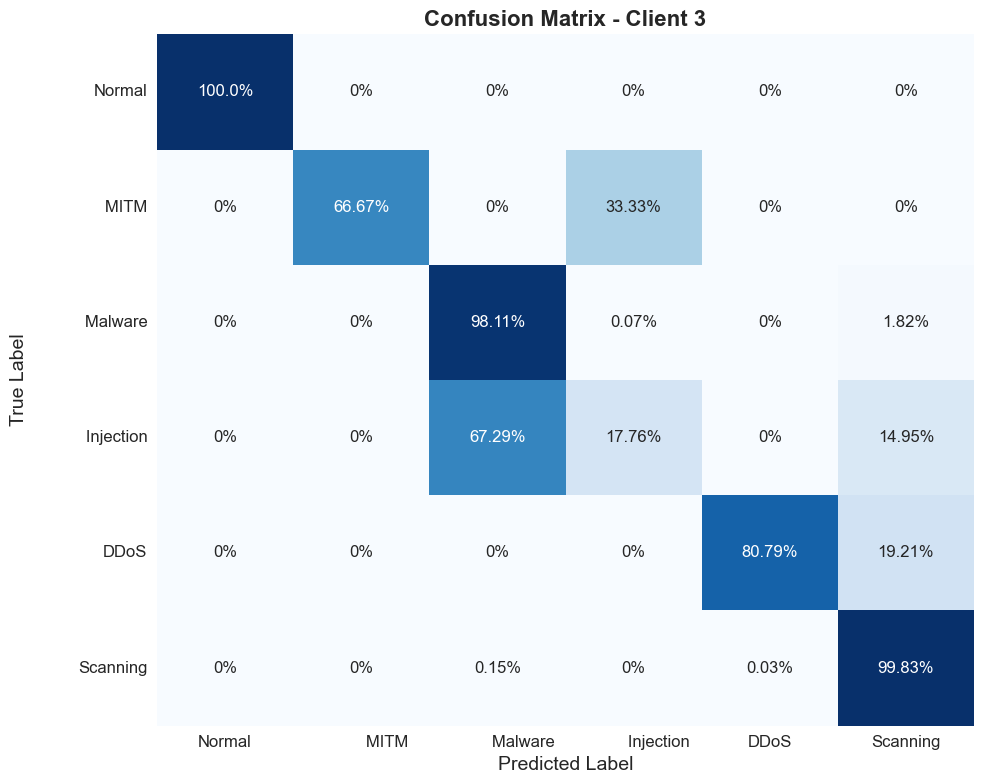

Visualization completed! All plots have been saved as PNG files.


In [ ]:
# Define class names based on the original dataset
attack_class_names = [
    'Normal', 
    '           MITM', 
    '           Malware', 
    '           Injection', 
    'DDoS', 
    'Scanning'
]

# Convert raw counts to percentages for global model
cm = np.array(rounds_data[9]['global_model']['confusion_matrix'])
cm_percentages = (cm / cm.sum(axis=1)[:, np.newaxis] * 100).round(2)

def plot_confusion_matrix(cm, classes, round_num, model_type, client_id=None):
    """
    Plot confusion matrix for a model with percentage values
    """
    plt.figure(figsize=(10, 8))
    
    # Create annotation text with percentage symbols
    annot = np.array([[f'{val}%' if val != 0 else '0%' for val in row] for row in cm])
    
    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', 
                xticklabels=classes, yticklabels=classes, cbar=False)
    
    title = f'Confusion Matrix'
    if model_type == 'global':
        title += ' - Global Model'
    else:
        title += f' - Client {client_id}'
    
    plt.title(title, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    
    # Save the figure
    if model_type == 'global':
        filename = f'results/confusion_matrix_round_{round_num}_global.png'
    else:
        filename = f'results/confusion_matrix_round_{round_num}_client_{client_id}.png'
    
    plt.savefig(filename, dpi=300)
    plt.show()

# Plot global model confusion matrix
plot_confusion_matrix(cm_percentages, attack_class_names, 10, 'global')

# Plot last round confusion matrices for all clients
last_round = rounds_data[-1]

# Determine the shape to ensure we have the right class names
num_classes = cm.shape[0]
if num_classes < len(attack_class_names):
    class_names = attack_class_names[:num_classes]
else:
    class_names = attack_class_names

for client_id in range(4):
    cm = np.array(last_round['local_models'][str(client_id)]['confusion_matrix'])
    cm_percentages = (cm / cm.sum(axis=1)[:, np.newaxis] * 100).round(2)
    plot_confusion_matrix(cm_percentages, class_names, num_rounds, 'client', client_id)


print("Visualization completed! All plots have been saved as PNG files.")


## Execution Time

In [ ]:
import json

# Load the JSON file
with open('fl_metrics.json', 'r') as file:
    data = json.load(file)

# Extract total_latency values
latencies = [round_data['total_latency'] for round_data in data['rounds']]

# Compute metrics
e2e_execution_time = sum(latencies)
mean_round_execution_time = e2e_execution_time / len(latencies)

# Display results
print("Execution Time Metrics:")
print(f"Total Rounds: {len(latencies)}")
print(f"E2E Execution Time: {e2e_execution_time:.2f} seconds")
print(f"Mean Round Execution Time: {mean_round_execution_time:.2f} seconds")


Execution Time Metrics:
Total Rounds: 10
E2E Execution Time: 3706.64 seconds
Mean Round Execution Time: 370.66 seconds


## Gas Used and Transaction time

Total Gas Used: 1761400


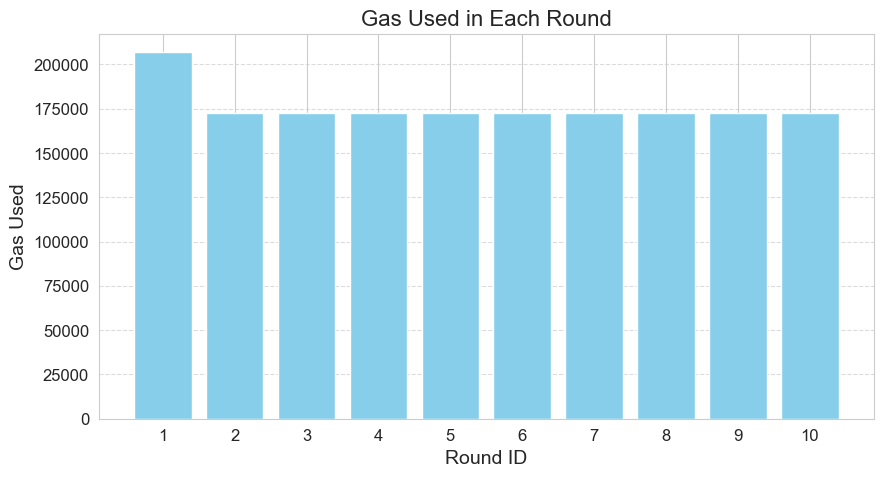

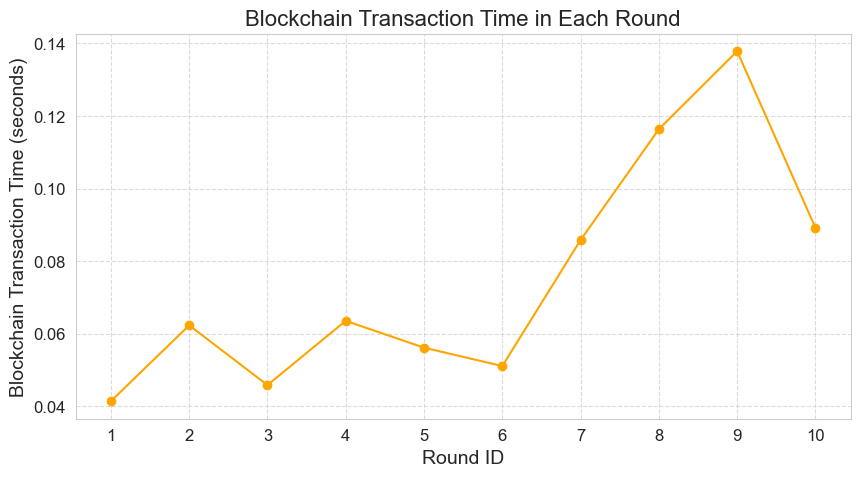

In [ ]:
import json
import matplotlib.pyplot as plt

# Load the JSON data
with open('fl_metrics.json', 'r') as file:
    data = json.load(file)

# Extract rounds
rounds = data['rounds']

# Extract gas used and blockchain transaction time for each round
round_ids = [round_data['round_id'] for round_data in rounds]
gas_used = [round_data['global_model']['gas_used'] for round_data in rounds]
blockchain_transaction_time = [round_data['global_model']['blockchain_transaction_time'] for round_data in rounds]

# Calculate total gas used
total_gas_used = sum(gas_used)
print(f"Total Gas Used: {total_gas_used}")

# Visualization for Gas Used
plt.figure(figsize=(10, 5))
plt.bar(round_ids, gas_used, color='skyblue')
plt.xlabel('Round ID')
plt.ylabel('Gas Used')
plt.title('Gas Used in Each Round')
plt.xticks(round_ids)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Visualization for Blockchain Transaction Time
plt.figure(figsize=(10, 5))
plt.plot(round_ids, blockchain_transaction_time, marker='o', color='orange')
plt.xlabel('Round ID')
plt.ylabel('Blockchain Transaction Time (seconds)')
plt.title('Blockchain Transaction Time in Each Round')
plt.xticks(round_ids)
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.show()

# Federated Learning Accuracy Comparison (4-8-16 clients)

Federated Learning Accuracy Comparison Analysis

Analyzing 4 Clients...
  Average Accuracy: 0.9397 ± 0.0132
  Rounds: 10
  Range: 0.9193 - 0.9564

Analyzing 8 Clients...
  Average Accuracy: 0.9416 ± 0.0074
  Rounds: 10
  Range: 0.9345 - 0.9598

Analyzing 16 Clients...
  Average Accuracy: 0.9546 ± 0.0059
  Rounds: 10
  Range: 0.9448 - 0.9595

Creating comparison chart with 3 experiments...


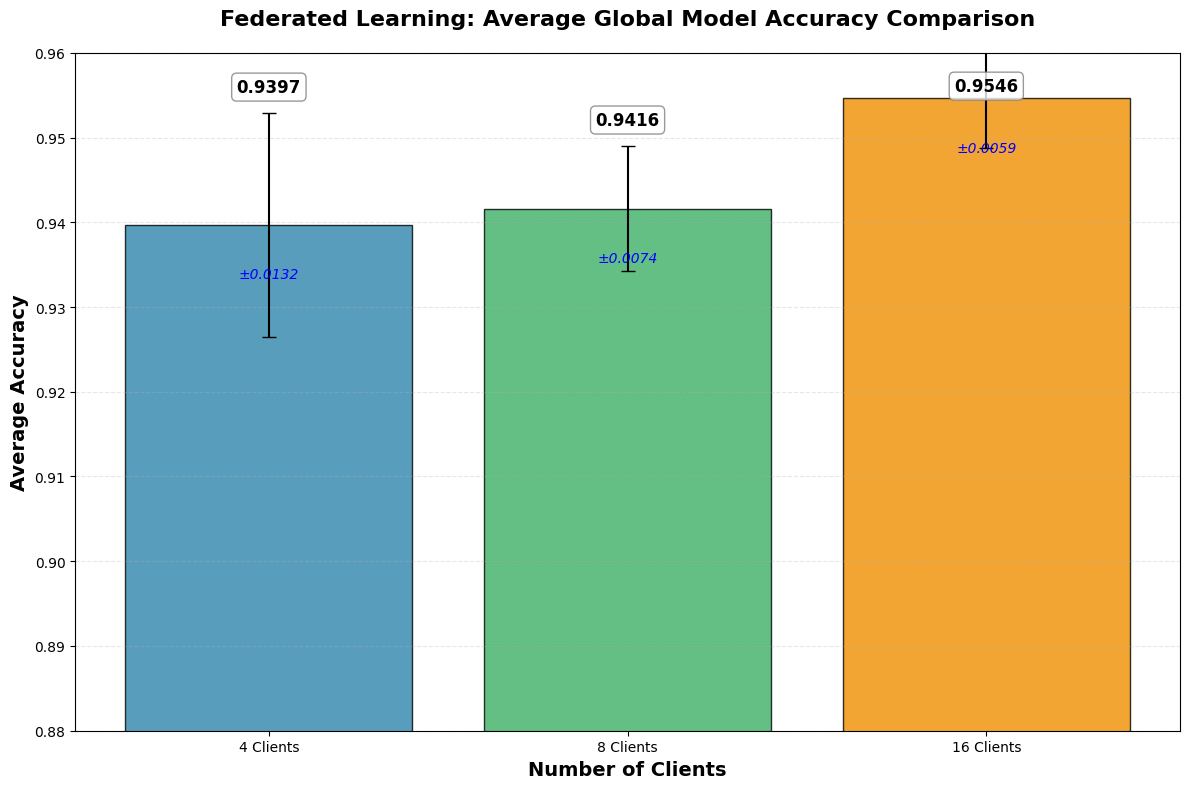


DETAILED ACCURACY ANALYSIS
Number of clients Avg Accuracy Std Dev Min Accuracy Max Accuracy  Rounds
        4 Clients       0.9397  0.0132       0.9193       0.9564      10
        8 Clients       0.9416  0.0074       0.9345       0.9598      10
       16 Clients       0.9546  0.0059       0.9448       0.9595      10

PERFORMANCE COMPARISON
4 Clients → 8 Clients:
  Accuracy change: +0.0019 (+0.21%)
  ✅ Improvement with more clients
8 Clients → 16 Clients:
  Accuracy change: +0.0130 (+1.38%)
  ✅ Improvement with more clients

Chart saved as 'federated_learning_accuracy_comparison.png'


In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

def load_metrics(file_path):
    """Load metrics from JSON file"""
    try:
        with open(file_path, 'r') as f:
            return json.load(f)
    except FileNotFoundError:
        print(f"File {file_path} not found")
        return None
    except json.JSONDecodeError:
        print(f"Error decoding JSON from {file_path}")
        return None

def calculate_average_accuracy(metrics_data):
    """Calculate average global model accuracy across all rounds"""
    if not metrics_data or 'rounds' not in metrics_data:
        return None, 0, []
    
    accuracies = []
    for round_data in metrics_data['rounds']:
        if 'global_model' in round_data and 'accuracy' in round_data['global_model']:
            accuracies.append(round_data['global_model']['accuracy'])
    
    if not accuracies:
        return None, 0, []
    
    avg_accuracy = np.mean(accuracies)
    std_accuracy = np.std(accuracies)
    
    return avg_accuracy, std_accuracy, accuracies

def analyze_experiments():
    """Analyze all three experiments and create comparison"""
    
    experiments = {
        '4 Clients': 'fl_metrics-4c.json',
        '8 Clients': 'fl_metrics-8clients.json',  
        '16 Clients': 'fl_metrics-16clients.json' 
    }
    
    results = {}
    detailed_results = {}
    
    for exp_name, file_path in experiments.items():
        print(f"\nAnalyzing {exp_name}...")
        
        # Try main file path first
        if Path(file_path).exists():
            metrics = load_metrics(file_path)
        
        
        if metrics:
            avg_acc, std_acc, all_accuracies = calculate_average_accuracy(metrics)
            if avg_acc is not None:
                results[exp_name] = avg_acc
                detailed_results[exp_name] = {
                    'avg_accuracy': avg_acc,
                    'std_accuracy': std_acc,
                    'all_accuracies': all_accuracies,
                    'num_rounds': len(all_accuracies),
                    'min_accuracy': min(all_accuracies),
                    'max_accuracy': max(all_accuracies)
                }
                print(f"  Average Accuracy: {avg_acc:.4f} ± {std_acc:.4f}")
                print(f"  Rounds: {len(all_accuracies)}")
                print(f"  Range: {min(all_accuracies):.4f} - {max(all_accuracies):.4f}")
            else:
                print(f"  No accuracy data found in {exp_name}")
        else:
            print(f"  Could not load metrics for {exp_name}")
    
    return results, detailed_results

def create_comparison_chart(results, detailed_results):
    """Create bar chart comparing average accuracies"""
    
    if not results:
        print("No data to plot!")
        return
    
    # Prepare data
    experiments = list(results.keys())
    avg_accuracies = list(results.values())
    std_errors = [detailed_results[exp]['std_accuracy'] for exp in experiments]
    
    # Create the plot
    plt.figure(figsize=(12, 8))
    
    # Create bar chart
    bars = plt.bar(experiments, avg_accuracies, 
                   yerr=std_errors, 
                   capsize=5,
                   color=['#2E86AB', "#3CB064", '#F18F01'],
                   alpha=0.8,
                   edgecolor='black',
                   linewidth=1)
    
    # Customize the chart
    plt.title('Federated Learning: Average Global Model Accuracy Comparison', 
              fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Number of Clients', fontsize=14, fontweight='bold')
    plt.ylabel('Average Accuracy', fontsize=14, fontweight='bold')
    
    # Set fixed y-axis limits for better comparison
    plt.ylim(0.88, 0.96)
    
    # Add value labels on bars with better positioning
    for i, (bar, avg_acc, std_err) in enumerate(zip(bars, avg_accuracies, std_errors)):
        height = bar.get_height()
        # Position label above the error bar, but ensure it's within plot limits
        label_y = min(height + std_err + 0.002, 0.955)  # Keep within y-limit
        
        plt.text(bar.get_x() + bar.get_width()/2., label_y,
                f'{avg_acc:.4f}',  # Show 4 decimal places for precision
                ha='center', va='bottom', fontweight='bold', fontsize=12,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='gray'))
        
        # Add standard deviation below the bar
        plt.text(bar.get_x() + bar.get_width()/2., height - 0.005,
                f'±{std_err:.4f}',
                ha='center', va='top', fontsize=10, style='italic',
                color='blue')
    
    # Add grid
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Improve layout
    plt.tight_layout()
    
    # Save the figure
    plt.savefig('results/federated_learning_accuracy_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return bars
# TODO: Calculate the average latency in each experiment and include it in the detailed analysis table

def create_detailed_analysis_table(detailed_results):
    """Create a detailed analysis table"""
    
    if not detailed_results:
        return
    
    print("\n" + "="*80)
    print("DETAILED ACCURACY ANALYSIS")
    print("="*80)
    
    # Create DataFrame for better formatting
    data = []
    for exp_name, results in detailed_results.items():
        data.append({
            'Number of clients': exp_name,
            'Avg Accuracy': f"{results['avg_accuracy']:.4f}",
            'Std Dev': f"{results['std_accuracy']:.4f}",
            'Min Accuracy': f"{results['min_accuracy']:.4f}",
            'Max Accuracy': f"{results['max_accuracy']:.4f}",
            'Rounds': results['num_rounds']
        })
    
    df = pd.DataFrame(data)
    print(df.to_string(index=False))
    
    # Calculate improvement/degradation
    if len(detailed_results) >= 2:
        print("\n" + "="*50)
        print("PERFORMANCE COMPARISON")
        print("="*50)
        
        exp_names = list(detailed_results.keys())
        for i in range(1, len(exp_names)):
            prev_acc = detailed_results[exp_names[i-1]]['avg_accuracy']
            curr_acc = detailed_results[exp_names[i]]['avg_accuracy']
            change = curr_acc - prev_acc
            change_pct = (change / prev_acc) * 100
            
            print(f"{exp_names[i-1]} → {exp_names[i]}:")
            print(f"  Accuracy change: {change:+.4f} ({change_pct:+.2f}%)")
            
            if change > 0:
                print(f"  ✅ Improvement with more clients")
            else:
                print(f"  ⚠️  Degradation with more clients")

def main():
    """Main function to run the analysis"""
    
    print("Federated Learning Accuracy Comparison Analysis")
    print("=" * 50)
    
    # Analyze experiments
    results, detailed_results = analyze_experiments()
    
    if not results:
        print("\nNo valid experiment data found!")
        print("Please make sure you have JSON files with the following names:")
        print("- fl_metrics_4clients.json (or similar for 4 clients)")
        print("- fl_metrics_8clients.json (or similar for 8 clients)")
        print("- fl_metrics_16clients.json (or similar for 16 clients)")
        return
    
    # Create comparison chart
    print(f"\nCreating comparison chart with {len(results)} experiments...")
    create_comparison_chart(results, detailed_results)
    
    # Create detailed analysis
    create_detailed_analysis_table(detailed_results)
    
    print(f"\nChart saved as 'federated_learning_accuracy_comparison.png'")

if __name__ == "__main__":
    main()

 Clients  Centralized  Block-HFL
       4       320.87     116.67
       8       565.28     307.00
      16       677.08     379.67


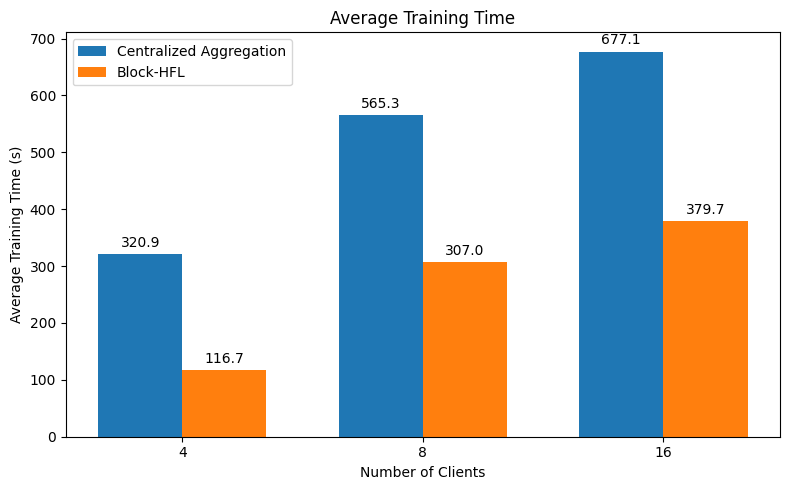


Saved figure to: avg_training_time_all_rounds.png


In [11]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ---- 1) Point to your files ----
FILES = {
    "Centralized-4c": "Centralized Aggregation-4c.json",
    "Centralized-8c": "Centralize Aggregation-8c.json",
    "Centralized-16c": "Centralized Aggregation-16c.json",
    "BlockHFL-4c": "fl_metrics-4c.json",
    "BlockHFL-8c": "fl_metrics-8clients.json",
    "BlockHFL-16c": "fl_metrics-16clients.json",
}

# ---- 2) Helper: average training time over ALL available rounds ----
def avg_training_time_all_rounds(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing file: {path}")
    with open(path, "r") as f:
        data = json.load(f)

    total = 0.0
    count = 0
    for rnd in data.get("rounds", []):   # all rounds in the file
        for client_data in rnd.get("local_models", {}).values():
            if "training_time" in client_data:
                total += float(client_data["training_time"])
                count += 1
    return (total / count) if count else np.nan

# ---- 3) Compute the averages into a tidy DataFrame ----
rows = []
for clients in [4, 8, 16]:
    centralized_key = f"Centralized-{clients}c"
    blockhfl_key    = f"BlockHFL-{clients}c"
    rows.append({
        "Clients": clients,
        "Centralized": avg_training_time_all_rounds(FILES[centralized_key]),
        "Block-HFL":   avg_training_time_all_rounds(FILES[blockhfl_key]),
    })
df = pd.DataFrame(rows)

# Optional: round for display
df_disp = df.copy()
df_disp[["Centralized","Block-HFL"]] = df_disp[["Centralized","Block-HFL"]].round(2)
print(df_disp.to_string(index=False))

# ---- 4) Plot grouped bar chart (matplotlib; one plot; no explicit colors) ----
x = np.arange(len(df))           # positions for groups (4,8,16)
width = 0.35                     # bar width

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, df["Centralized"].values, width, label="Centralized Aggregation")
bars2 = ax.bar(x + width/2, df["Block-HFL"].values,   width, label="Block-HFL")

ax.set_title("Average Training Time")
ax.set_xlabel("Number of Clients")
ax.set_ylabel("Average Training Time (s)")
ax.set_xticks(x)
ax.set_xticklabels(df["Clients"].astype(str).tolist())
ax.legend()

# Annotate each bar with its height
def autolabel(rects):
    for rect in rects:
        h = rect.get_height()
        ax.annotate(f"{h:.1f}",
                    xy=(rect.get_x() + rect.get_width()/2, h),
                    xytext=(0, 3), textcoords="offset points",
                    ha="center", va="bottom")
autolabel(bars1)
autolabel(bars2)

fig.tight_layout()
out_path = "avg_training_time_all_rounds.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"\nSaved figure to: {out_path}")
